In [7]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv("Taxi_data.csv")
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               float64
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           float64
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(13), int64(2), object(3)
memory usage: 879.6+ MB


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,6.339567e+06,6.339567e+06,6.405008e+06,6.339567e+06,6.405008e+06,6.405008e+06,6.339567e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06,6.405008e+06
mean,1.669624e+00,1.515333e+00,2.929644e+00,1.059908e+00,1.647323e+02,1.626627e+02,1.270298e+00,1.269411e+01,1.115456e+00,4.923182e-01,2.189342e+00,3.488395e-01,2.979870e-01,1.866315e+01,2.275662e+00
std,4.703484e-01,1.151594e+00,8.315911e+01,8.118432e-01,6.554374e+01,6.991261e+01,4.739985e-01,1.212730e+01,1.260054e+00,7.374184e-02,2.760028e+00,1.766978e+00,3.385937e-02,1.475736e+01,7.352646e-01
min,1.000000e+00,0.000000e+00,-3.062000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.238000e+03,-2.700000e+01,-5.000000e-01,-9.100000e+01,-3.574000e+01,-3.000000e-01,-1.242300e+03,-2.500000e+00
25%,1.000000e+00,1.000000e+00,9.600000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,1.116000e+01,2.500000e+00
50%,2.000000e+00,1.000000e+00,1.600000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,9.000000e+00,5.000000e-01,5.000000e-01,1.950000e+00,0.000000e+00,3.000000e-01,1.430000e+01,2.500000e+00
75%,2.000000e+00,2.000000e+00,2.930000e+00,1.000000e+00,2.340000e+02,2.340000e+02,2.000000e+00,1.400000e+01,2.500000e+00,5.000000e-01,2.860000e+00,0.000000e+00,3.000000e-01,1.980000e+01,2.500000e+00
max,2.000000e+00,9.000000e+00,2.102401e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,4.265000e+03,1.130100e+02,3.080000e+01,1.100000e+03,9.105000e+02,3.000000e-01,4.268300e+03,2.750000e+00


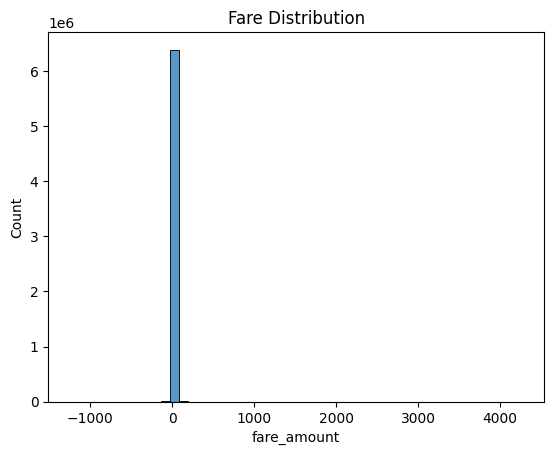

In [10]:
sns.histplot(df['fare_amount'], bins=50)
plt.title("Fare Distribution")
plt.show()

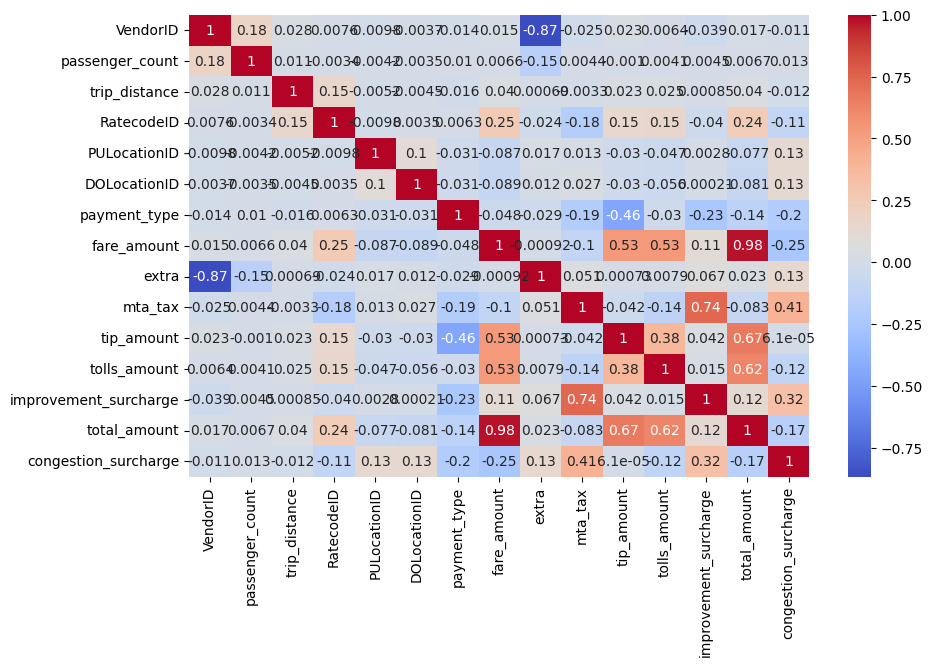

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

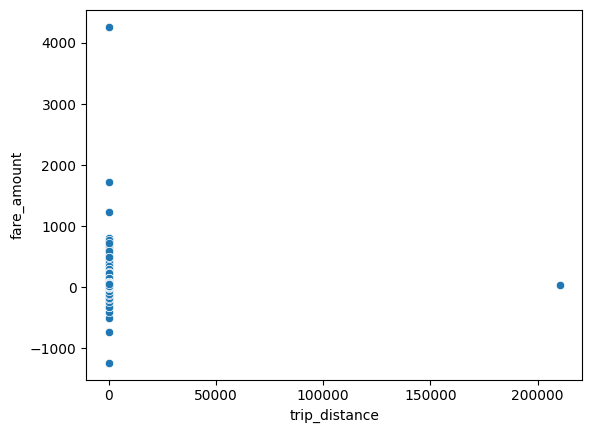

In [20]:
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.show()

In [21]:
print(df['tpep_pickup_datetime'].dtype)

KeyError: 'tpep_pickup_datetime'

In [17]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

KeyError: 'tpep_pickup_datetime'

In [22]:
# Extract time features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.dayofweek

# Drop unnecessary columns
df = df.drop(['tpep_pickup_datetime', 'tpep_dropoff_datetime'], axis=1)

KeyError: 'tpep_pickup_datetime'

In [23]:
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

In [25]:
print(X_train.dtypes)

VendorID                 float64
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type             float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
pickup_hour                int32
pickup_day                 int32
dtype: object


In [26]:
print(df['store_and_fwd_flag'].unique())

[ 0.  1. nan]


In [27]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

In [28]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(0)

In [29]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype(int)

In [30]:
print(X_train.dtypes)

VendorID                 float64
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type             float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
pickup_hour                int32
pickup_day                 int32
dtype: object


In [31]:
print(df['store_and_fwd_flag'].dtype)

int64


In [32]:
# 1. Clean column
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype(str)
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].str.strip().str.upper()
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(0)
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype(int)

In [33]:
# 2. Split AGAIN (very important)
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [34]:
# 3. Verify (must be empty)
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [35]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [36]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [37]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    max_samples=0.5,   # uses only 50% data per tree
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [38]:
def evaluate(y_true, y_pred):
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

In [39]:
print("Linear Regression")
evaluate(y_test, y_pred_lr)

print("\nRandom Forest")
evaluate(y_test, y_pred_rf)

Linear Regression
MAE: 0.22923512182261938
RMSE: 0.40202692448118627
R2 Score: 0.9988958718439922

Random Forest
MAE: 0.37743002587930324
RMSE: 1.3619170400640566
R2 Score: 0.9873290110212645


In [41]:
grid = GridSearchCV(
    RandomForestRegressor(),
    {
        'n_estimators': [50],
        'max_depth': [10]
    },
    cv=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [10], 'n_estimators': [50]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [42]:
df_sample = df.sample(200000, random_state=42)

In [43]:
print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 50}


In [44]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
evaluate(y_test, y_pred)

MAE: 0.38653520898639804
RMSE: 1.2969210276876022
R2 Score: 0.9885095703206709


In [45]:
import joblib

joblib.dump(best_model, "taxi_fare_model.pkl")

['taxi_fare_model.pkl']